# Gravity-wave analysis (h-NUMO `gravity_wave` test case)

Internal gravity-wave propagation test based on Chen (2025). Two layers, flow initially at rest with a cosine-bell hump
on the interface, non-rotating. Excites a fast barotropic and a slower
baroclinic gravity wave.

This notebook bins the layer-2 thickness deviation by great-circle distance
from the hump center at two snapshot times, estimates the barotropic
wavefront speed from the shift in the leading edge, and renders lon-lat maps.

In [1]:
import sys, os, re
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
from numo_vtk import read_vtk_ascii, great_circle_km, radial_bin_mean, plot_latlon_map, snapshot_time_hours

%matplotlib inline

In [2]:
# ---------------- SETTINGS ----------------
RUNDIR = '/Users/yao/Documents/Code/h-NUMO/output/sphere/gravity_wave/'                                  # directory with the VTK output
FPREFIX = 'mlswe_sphere_1000.0000_dg_rk35_l002_'  # layer-2 (bottom) files
IDX1 = 16    # snapshot index for the earlier time
IDX2 = 32    # snapshot index for the later time
TIME_RESTART_HOURS = 0.5  # time_restart in numo3d.in
# dt (bcl time step, seconds) -- auto-detected from FPREFIX (h-NUMO embeds it
# literally, e.g. "..._500.0000_..."); override manually if that fails. This
# matters because the *actual* spacing between VTK snapshots is
# irestart*dt (irestart = NINT(time_restart_seconds/dt)), which only equals
# TIME_RESTART_HOURS exactly when dt evenly divides 1800s -- see
# numo_vtk.snapshot_time_hours. A wrong/hardcoded time-per-snapshot here
# silently mislabels snapshot times and biases the wave-speed estimate
# below (this bit us already with a dt=400 run -- don't reintroduce it).
DT_SECONDS = float(re.search(r'_(\d+\.\d+)_', FPREFIX).group(1))
BACKGROUND = 1000.0      # resting layer thickness (m)
LON0, LAT0 = 0.0, 0.0    # hump center (radians)
BINWIDTH_KM = 500.0
BTP_THRESHOLD = 0.01    # m; deviation magnitude marking the leading edge of
                        # the fast (barotropic) wave, well above the ~0.001-
                        # 0.002m interpolation noise floor but well below
                        # real signal (tens of m near source, ~0.05m at the
                        # barotropic front itself)
BCL_THRESHOLD = 2.0     # m; deviation magnitude marking the edge of the
                        # baroclinic disturbance -- much larger than
                        # BTP_THRESHOLD since the baroclinic signal itself is
                        # O(10s of m). CAVEAT: at short run times the
                        # baroclinic front has barely moved beyond the
                        # initial hump's own footprint (radius ~1112km), so
                        # this measures the edge of the still-adjusting
                        # source region more than a cleanly separated
                        # propagating front -- Chen's own paper only gets a
                        # clean baroclinic speed by running ~150-225h, far
                        # longer than typical short test runs here.
RHO1, RHO2 = 1000.0, 1020.0  # layer densities (kg/m^3), from
                              # initial_conditions_sphere.F90's 'gravity_wave'
                              # case (paper's other tested config: 1040)
GRAVITY = 9.81
PHI1, PHI2 = 1000.0, 1000.0   # background layer thicknesses (m)
PREDICTED_BTP_SPEED = np.sqrt(GRAVITY * (PHI1 + PHI2))
G_REDUCED = GRAVITY * (RHO2 - RHO1) / RHO1
PREDICTED_BCL_SPEED = np.sqrt(G_REDUCED * PHI1 * PHI2 / (PHI1 + PHI2))
# -------------------------------------------

In [3]:
t1 = snapshot_time_hours(IDX1, DT_SECONDS, TIME_RESTART_HOURS)
t2 = snapshot_time_hours(IDX2, DT_SECONDS, TIME_RESTART_HOURS)
f1 = os.path.join(RUNDIR, f'{FPREFIX}{IDX1:04d}.vtk')
f2 = os.path.join(RUNDIR, f'{FPREFIX}{IDX2:04d}.vtk')

d1 = read_vtk_ascii(f1, fields=['h'])
d2 = read_vtk_ascii(f2, fields=['h'])
print(f"Loaded {len(d1['h'])} points from {f1} at t={t1:.1f}h")
print(f"Loaded {len(d2['h'])} points from {f2} at t={t2:.1f}h")

Loaded 150000 points from /Users/yao/Documents/Code/h-NUMO/output/sphere/gravity_wave/mlswe_sphere_1000.0000_dg_rk35_l002_0016.vtk at t=8.9h
Loaded 150000 points from /Users/yao/Documents/Code/h-NUMO/output/sphere/gravity_wave/mlswe_sphere_1000.0000_dg_rk35_l002_0032.vtk at t=17.8h


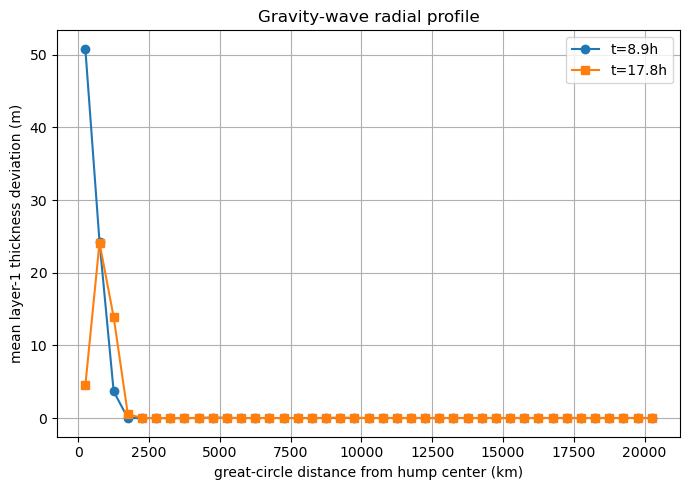

In [4]:
dist1 = great_circle_km(LON0, LAT0, d1['lon'], d1['lat'])
dist2 = great_circle_km(LON0, LAT0, d2['lon'], d2['lat'])
dev1 = d1['h'] - BACKGROUND
dev2 = d2['h'] - BACKGROUND

centers, mean1 = radial_bin_mean(dist1, dev1, BINWIDTH_KM)
_, mean2 = radial_bin_mean(dist2, dev2, BINWIDTH_KM)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(centers, mean1, '-o', label=f't={t1:.1f}h')
ax.plot(centers, mean2, '-s', label=f't={t2:.1f}h')
ax.set_xlabel('great-circle distance from hump center (km)')
ax.set_ylabel('mean layer-1 thickness deviation (m)')
ax.set_title('Gravity-wave radial profile')
ax.legend(); ax.grid(True)
fig.tight_layout()

In [5]:
# Wave-speed estimate: a mode's front position is the outermost radius where
# the signal is still distinguishable from the background at that mode's
# characteristic amplitude -- i.e. the leading edge -- not wherever
# |deviation| happens to be locally largest. The barotropic mode uses a
# small threshold (its own signal is only ~0.05m) and the baroclinic mode a
# much larger one (its signal is O(10s of m)), so each picks out its own
# front rather than the other's.
def leading_edge(centers, mean, threshold):
    absmean = np.nan_to_num(np.abs(mean))
    above = np.where(absmean > threshold)[0]
    if len(above) == 0:
        return np.nan
    i = above[-1]
    # Linear-interpolate the threshold crossing between bin i (above
    # threshold) and bin i+1 (below) for sub-bin precision.
    if i == len(centers) - 1 or np.isnan(mean[i + 1]):
        return centers[i]
    y0, y1 = absmean[i], absmean[i + 1]
    if y0 == y1:
        return centers[i]
    frac = (y0 - threshold) / (y0 - y1)
    return centers[i] + frac * (centers[i + 1] - centers[i])

r1_btp = leading_edge(centers, mean1, BTP_THRESHOLD)
r2_btp = leading_edge(centers, mean2, BTP_THRESHOLD)
speed_btp = (r2_btp - r1_btp) * 1000.0 / ((t2 - t1) * 3600.0)

r1_bcl = leading_edge(centers, mean1, BCL_THRESHOLD)
r2_bcl = leading_edge(centers, mean2, BCL_THRESHOLD)
speed_bcl = (r2_bcl - r1_bcl) * 1000.0 / ((t2 - t1) * 3600.0)

print(f"Barotropic front: t={t1:.1f}h -> r={r1_btp:.0f} km,  t={t2:.1f}h -> r={r2_btp:.0f} km")
print(f"Estimated barotropic speed: {speed_btp:.1f} m/s  (predicted ~{PREDICTED_BTP_SPEED:.1f} m/s)")

print(f"\nBaroclinic front: t={t1:.1f}h -> r={r1_bcl:.0f} km,  t={t2:.1f}h -> r={r2_bcl:.0f} km")
print(f"Estimated baroclinic speed: {speed_bcl:.1f} m/s  (predicted ~{PREDICTED_BCL_SPEED:.1f} m/s)")
print("(Baroclinic estimate is unreliable at short run times -- see BCL_THRESHOLD comment above; "
      "Chen's paper needed ~150-225h of simulated time for a clean baroclinic-front measurement.)")

Barotropic front: t=8.9h -> r=5522 km,  t=17.8h -> r=9979 km
Estimated barotropic speed: 139.3 m/s  (predicted ~140.1 m/s)

Baroclinic front: t=8.9h -> r=1478 km,  t=17.8h -> r=1695 km
Estimated baroclinic speed: 6.8 m/s  (predicted ~9.9 m/s)
(Baroclinic estimate is unreliable at short run times -- see BCL_THRESHOLD comment above; Chen's paper needed ~150-225h of simulated time for a clean baroclinic-front measurement.)


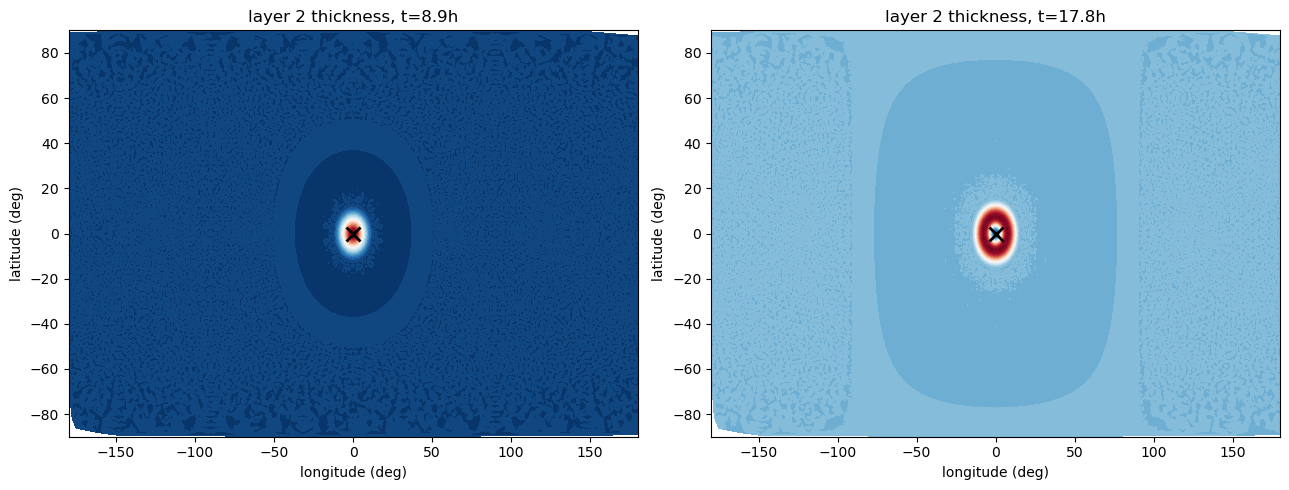

In [6]:
fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_latlon_map(axes[0], d1['lon'], d1['lat'], d1['h'],
                 title=f'layer 2 thickness, t={t1:.1f}h',
                 mark_point=(np.degrees(LON0), np.degrees(LAT0)))
plot_latlon_map(axes[1], d2['lon'], d2['lat'], d2['h'],
                 title=f'layer 2 thickness, t={t2:.1f}h',
                 mark_point=(np.degrees(LON0), np.degrees(LAT0)))
fig2.tight_layout()